[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pachterlab/OP_2025/blob/main/analysis_scripts/2_Label_Correction_Reanalysis.ipynb)

# Clone github repo

In [ ]:
!git clone https://github.com/pachterlab/OP_2025.git
%cd /content/OP_2025/

# Download Data

In [ ]:
!mkdir -p omics_data
!wget -P omics_adata https://data.caltech.edu/records/j57wp-0pp06/files/rat_genes_meta.h5ad?download=1
!mv omics_data/rat_genes_meta.h5ad?download=1 omics_data/rat_genes_meta.h5ad
!wget -P omics_adata https://data.caltech.edu/records/j57wp-0pp06/files/rat_transcripts.h5ad?download=1
!mv omics_data/rat_transcripts.h5ad?download=1 omics_data/rat_transcripts.h5ad


# Install Packages

In [ ]:
!pip install -qr requirements.txt 

In [1]:
# import packages

import sys
sys.path.append('analysis_scripts')

# numbers
import pandas as pd

# sc
import scanpy as sc
import anndata

# plots

from rat_friend import *

In [ ]:
import os
# In Colab, %cd already set CWD to repo root; locally the notebook runs from analysis_scripts/
if not os.path.exists('analysis_scripts'):
    os.chdir('../')

In [2]:
tissue_colors, _ = get_color_palettes()
color_dict = tissue_colors

# Label Correction

In [3]:
adata = anndata.read_h5ad("omics_data/rat_genes_meta.h5ad")
adata = adata[~adata.obs.outlier].copy()
adata.obs['old_tissue'] = adata.obs['tissue']
adata.obs.loc[adata.obs.barcode == 'SRR25251484', 'tissue'] = 'HYPOTH'
adata.obs.loc[adata.obs.barcode == 'SRR25251568', 'tissue'] = 'HIPPOC'
toss = ['SRR25251685', 'SRR25251610', 'SRR25251278']
adata = adata[[x not in toss for x in adata.obs.barcode],:]
#adata.write('omics_data/rat_RNA_meta.h5ad')
adata

/Users/ConradOakes/miniforge3/envs/rat_help/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


View of AnnData object with n_obs × n_vars = 861 × 24770
    obs: 'barcode', 'path', 'nac_path', 'mat_path', 'amb_path', 'time', 'sex', 'tissue', 'viallabel', 'calculated.variables.pct_body_fat_change', 'calculated.variables.pct_body_lean_change', 'calculated.variables.pct_body_fluid_change', 'calculated.variables.lactate_change_dueto_train', 'calculated.variables.vo2_max_change', 'calculated.variables.coll_time_train', 'calculated.variables.deathtime_after_train', 'calculated.variables.frozetime_after_train', 'pid', 'group', 'rank', 'nid', 'num_umi', 'outlier', 'original_out', 'old_tissue'
    var: 'gene_id', 'has_U_tr', 'eff_len', 'mt', 'ensembl_transcript_id', 'description', 'ensembl_gene_id', 'X3', 'X5', 'X6', 'X7', 'X8'
    uns: 'X_name'
    layers: 'ambiguous', 'spliced', 'unspliced'

# Normalize and Subset to Highly Variable

/Users/ConradOakes/miniforge3/envs/rat_help/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:291: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_counts"] = number


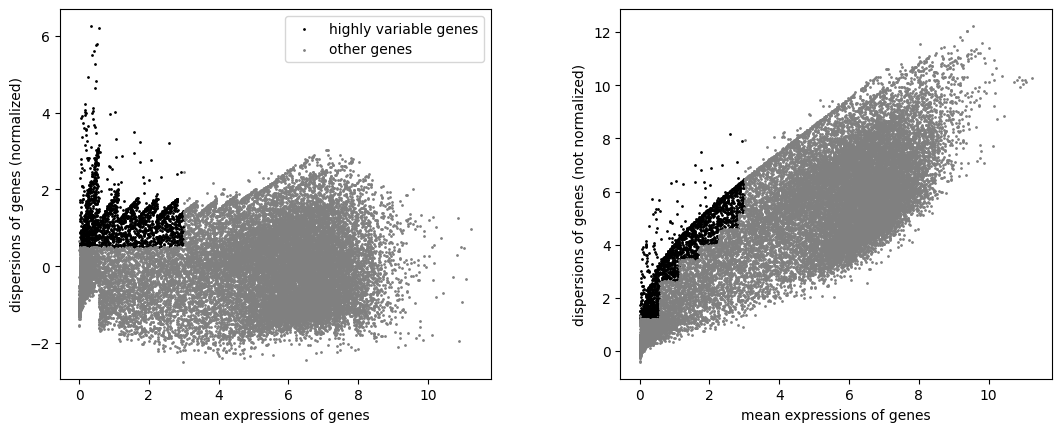

In [7]:
pre_norm_adata = adata.copy()
sc.pp.filter_genes(adata, min_counts=1)
adata.var_names_make_unique()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)
sc.pl.highly_variable_genes(adata)

# Plot PCA

/Users/ConradOakes/miniforge3/envs/rat_help/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:383: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


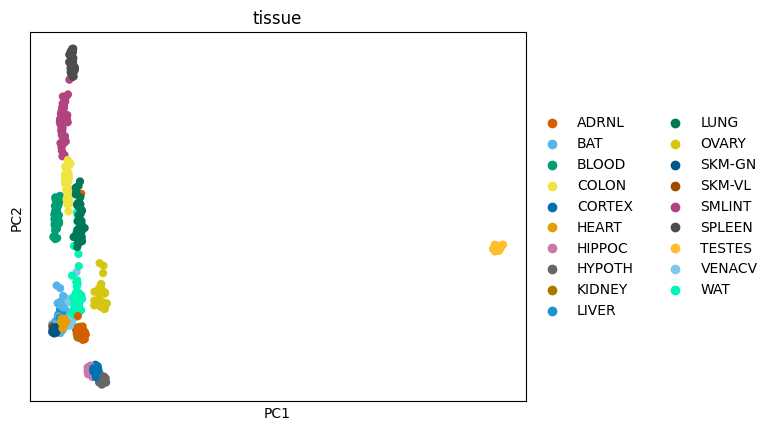

In [8]:
adata = adata[:, adata.var.highly_variable].copy()
sc.tl.pca(adata)
sc.pl.pca(adata, color='tissue', palette = color_dict, ncols=2,wspace=0.5)

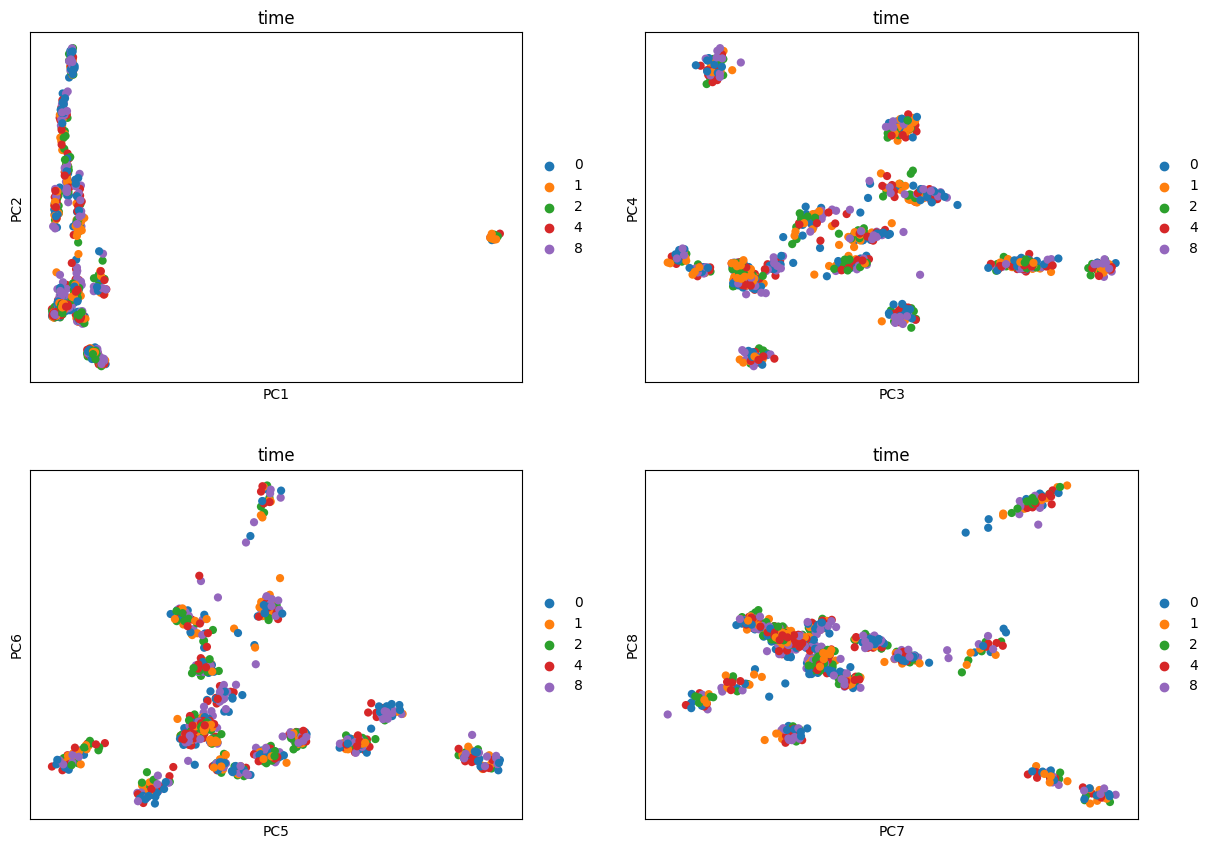

In [10]:
sc.pl.pca(adata, components = ['1,2', '3,4', '5,6', '7,8'], color='time', ncols=2,
          save = None)

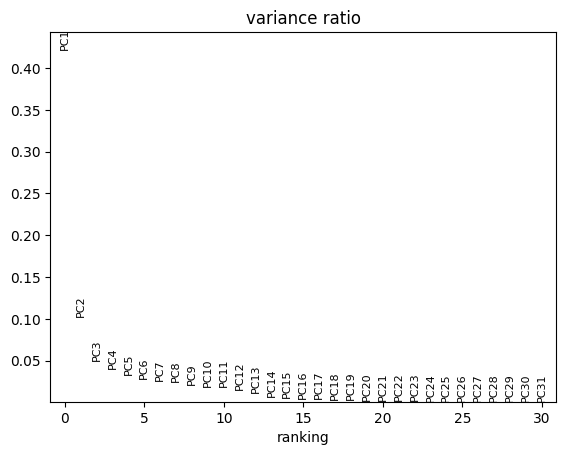

In [11]:
sc.pl.pca_variance_ratio(adata)

# Correct and Annotate Transcript Level Data

In [ ]:
transcript_adata = anndata.read_h5ad(f"omics_data/rat_transcripts.h5ad")
transcript_adata

AnnData object with n_obs × n_vars = 879 × 72032
    obs: 'barcode', 'path', 'nac_path', 'mat_path', 'amb_path', 'time', 'sex', 'tissue', 'viallabel', 'pid', 'calculated.variables.pct_body_fat_change', 'calculated.variables.pct_body_lean_change', 'calculated.variables.pct_body_fluid_change', 'calculated.variables.lactate_change_dueto_train', 'calculated.variables.vo2_max_change', 'calculated.variables.coll_time_train', 'calculated.variables.deathtime_after_train', 'calculated.variables.frozetime_after_train'
    var: 'gene_id', 'has_U_tr', 'eff_len'
    uns: 'X_name'
    layers: 'ambiguous', 'spliced', 'unspliced'

In [ ]:
gene_meta = pd.read_csv('metadata_csvs/t2go.csv')
adata.var = pd.merge(adata.var.reset_index(), gene_meta, left_on= 'gene_id', right_on='ensembl_transcript_id', how='left', suffixes=('', '_DROP')).filter(regex='^(?!.*_DROP)').set_index('index')
adata.var = adata.var.drop(['X4'], axis=1)
adata.var.head()

,gene_id,has_U_tr,eff_len,mt,ensembl_transcript_id,description,ensembl_gene_id,X3,X5,X6,X7,X8,n_counts,highly_variable,means,dispersions,dispersions_norm
index,,,,,,,,,,,,,,,,,
ENSRNOG00000000009,ENSRNOG00000000009,True,1198.722637,False,ENSRNOG00000000009,NA,ENSRNOG00000000009,Tmco5b,3,100064979,100083289,+,20807.0,True,2.737382,6.003363,1.564241
ENSRNOG00000000199,ENSRNOG00000000199,True,533.001304,False,ENSRNOG00000000199,RNA binding,ENSRNOG00000000199,RGD1559995,8,79215362,79216570,-,2435.0,True,1.126189,2.996884,0.836367
ENSRNOG00000000282,ENSRNOG00000000282,True,948.628772,False,ENSRNOG00000000282,"DNA-binding transcription factor activity, RNA...",ENSRNOG00000000282,Gsc2,11,83072138,83074126,+,9480.0,True,2.022644,5.220851,1.458259
ENSRNOG00000000376,ENSRNOG00000000376,False,80.156195,False,ENSRNOG00000000376,NA,ENSRNOG00000000376,LOC108349010,20,25051477,25051701,+,10.0,True,0.030989,1.863414,1.331804
ENSRNOG00000000507,ENSRNOG00000000507,True,1583.416956,False,ENSRNOG00000000507,"NA, photoreceptor outer segment, retina homeos...",ENSRNOG00000000507,Tulp1,20,6412171,6424073,-,4579.0,True,1.706284,5.184159,1.429489


In [ ]:
transcript_adata.obs = pd.merge(transcript_adata.obs.reset_index(), adata.obs, left_on= 'barcode', right_on='barcode', how='left', suffixes=('', '_DROP')).filter(regex='^(?!.*_DROP)').set_index('index').drop(['outlier'],axis=1)
transcript_adata = transcript_adata[~transcript_adata.obs.nid.isna()].copy()
transcript_adata.obs['tissue'] = transcript_adata.obs['tissue'].str.upper()
transcript_adata.obs['original_out'] = transcript_adata.obs['original_out'].astype('bool')
transcript_adata.write('omics_data/rat_RNA_transcript_meta.h5ad')
transcript_adata

/home/coakes/miniconda3/envs/rata/lib/python3.12/site-packages/pandas/core/generic.py:6329: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  self[name] = value


AnnData object with n_obs × n_vars = 861 × 72032
    obs: 'barcode', 'path', 'nac_path', 'mat_path', 'amb_path', 'time', 'sex', 'tissue', 'viallabel', 'pid', 'calculated.variables.pct_body_fat_change', 'calculated.variables.pct_body_lean_change', 'calculated.variables.pct_body_fluid_change', 'calculated.variables.lactate_change_dueto_train', 'calculated.variables.vo2_max_change', 'calculated.variables.coll_time_train', 'calculated.variables.deathtime_after_train', 'calculated.variables.frozetime_after_train', 'group', 'rank', 'nid', 'num_umi', 'original_out', 'old_tissue'
    var: 'gene_id', 'has_U_tr', 'eff_len'
    uns: 'X_name'
    layers: 'ambiguous', 'spliced', 'unspliced'